# Лабораторная: прогнозирование продаж (ARIMA / SARIMAX)

Структура: **2.1 EDA** → **декомпозиция** → **модели** → **оценка качества** → **итоговые выводы**.


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
from scipy import signal, stats
from scipy.fft import rfft, rfftfreq
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "retail_sales_mock_data.csv"
TARGET = "SalesAmount"
DATE_COL = "Date"
EXOG_COLS = ["Promotion", "HolidayMonth"]
SEASONAL_PERIOD = 12
HOLDOUT = 12


## 2.1 Разведочный анализ данных (EDA)

In [2]:
# Загрузка и приведение к временному ряду с месячной частотой
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

# Проверки качества данных
assert df[DATE_COL].is_unique, "Дубликаты дат"
assert df.isna().sum().sum() == 0, "Есть пропуски"

df = df.set_index(DATE_COL)
df.index = df.index.to_period("M").to_timestamp()  # начало месяца
df = df.asfreq("MS")  # месячная частота

y = df[TARGET] # то что будем предсказывать
exog = df[EXOG_COLS] # внешние переменные которые влияют на y

print(f"Период: {y.index.min().date()} — {y.index.max().date()}, n={len(y)}")
print(df.describe())
display(df.head())

Период: 2020-01-01 — 2023-12-01, n=48
        SalesAmount  Promotion  HolidayMonth
count     48.000000  48.000000     48.000000
mean   11768.541667   0.125000      0.083333
std     2257.544863   0.334219      0.279310
min     7783.000000   0.000000      0.000000
25%    10219.750000   0.000000      0.000000
50%    11851.000000   0.000000      0.000000
75%    13014.000000   0.000000      0.000000
max    17996.000000   1.000000      1.000000


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


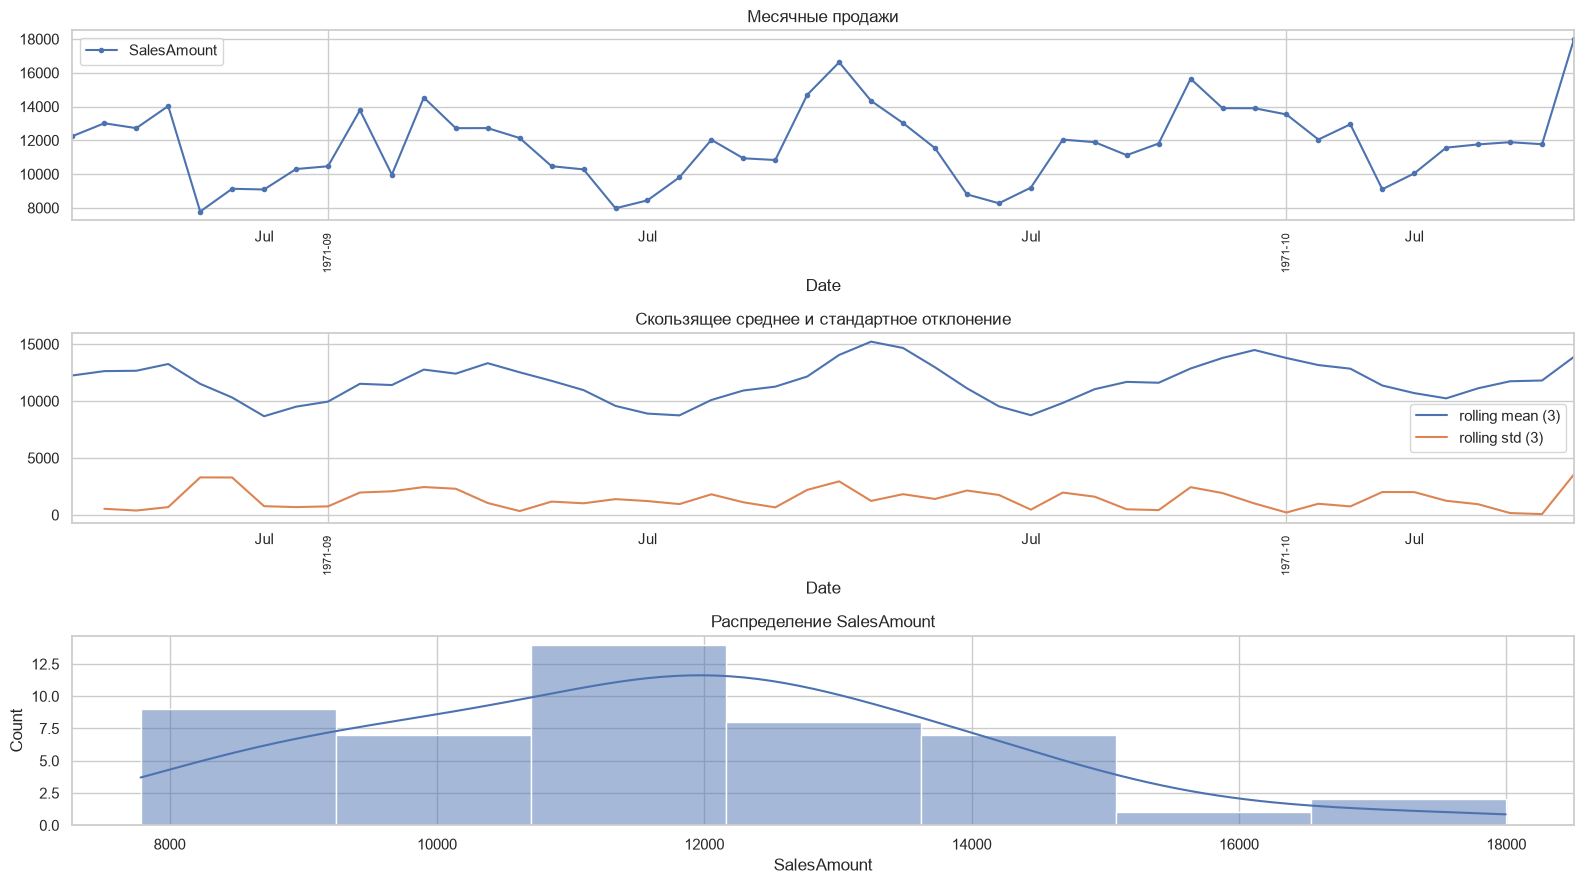

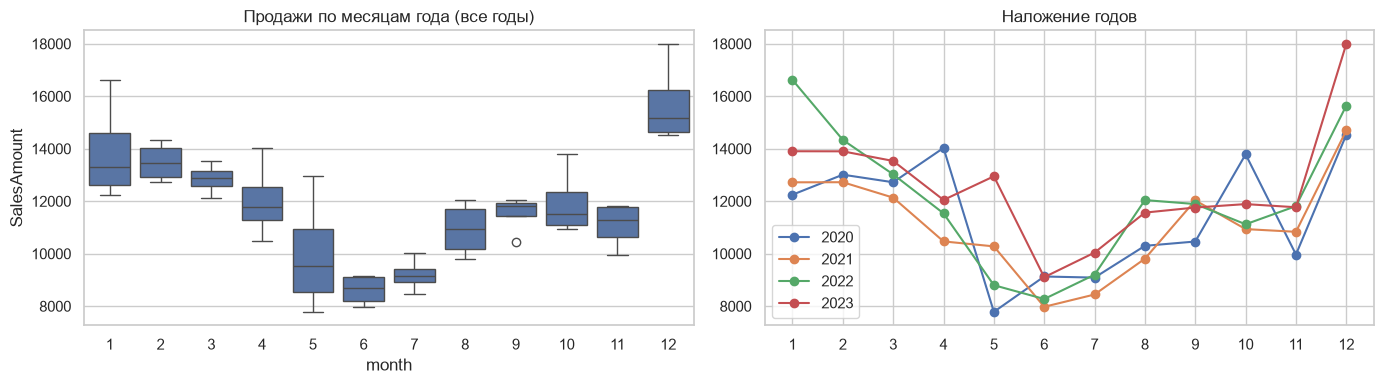

In [3]:
# Визуализации EDA: уровень, скользящие статистики, распределение
fig, axes = plt.subplots(3, 1, figsize=(16, 9))

y.plot(ax=axes[0], marker="o", markersize=3, label=TARGET)
axes[0].set_title("Месячные продажи")
axes[0].legend()

roll = y.rolling(3, min_periods=1)
roll.mean().plot(ax=axes[1], label="rolling mean (3)")
roll.std().plot(ax=axes[1], label="rolling std (3)")
axes[1].set_title("Скользящее среднее и стандартное отклонение")
axes[1].legend()

# По умолчанию matplotlib ставит подписи раз в полгода (январь/июль). Показываем каждый месяц.
for ax in (axes[0], axes[1]):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
    ax.set_xlim(y.index.min(), y.index.max())

sns.histplot(y, kde=True, ax=axes[2])
axes[2].set_title("Распределение SalesAmount")

plt.tight_layout()
plt.show()

# Сезонность по календарным месяцам и годам
df_plot = df.copy()
df_plot["year"] = df_plot.index.year
df_plot["month"] = df_plot.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df_plot, x="month", y=TARGET, ax=axes[0])
axes[0].set_title("Продажи по месяцам года (все годы)")

for year, g in df_plot.groupby("year"):
    axes[1].plot(g["month"], g[TARGET], marker="o", label=year)
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Наложение годов")
axes[1].legend()

plt.tight_layout()
plt.show()


Наложение годов показывает на то как сезон повторяется или нет из года в год\
Бокс плоты показывают в каком месяце больше продаж, а в каком меньше

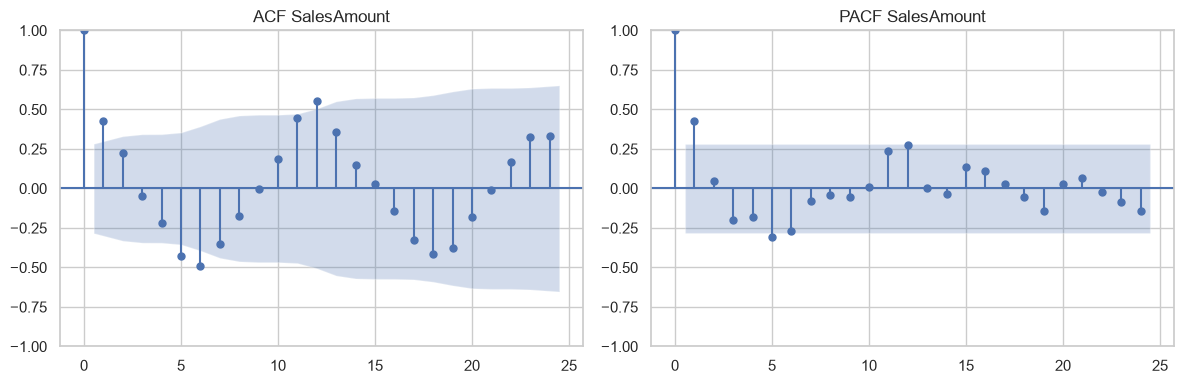

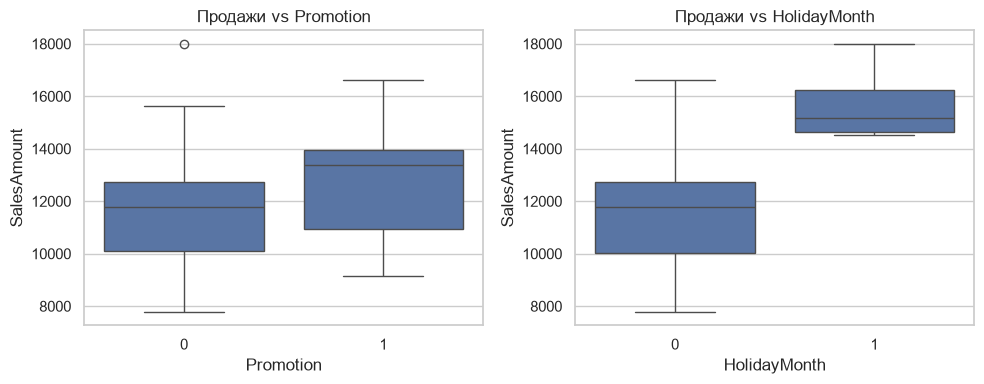

ADF на исходном ряду: stat=-4.514, p-value=0.0002
KPSS: stat=0.139, p-value=0.1000


/var/folders/9b/v9vdnqh91033xkzd2rbl32bc0000gn/T/ipykernel_63108/1894603444.py:19: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(y)
/var/folders/9b/v9vdnqh91033xkzd2rbl32bc0000gn/T/ipykernel_63108/1894603444.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(y, regression="c", nlags="auto")
/var/folders/9b/v9vdnqh91033xkzd2rbl32bc0000gn/T/ipykernel_63108/1894603444.py:22: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In rel

In [4]:
# ACF/PACF и связь с промо / праздниками
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=24, ax=axes[0])
axes[0].set_title("ACF SalesAmount")
plot_pacf(y, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF SalesAmount")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df.reset_index(), x="Promotion", y=TARGET, ax=axes[0])
axes[0].set_title("Продажи vs Promotion")
sns.boxplot(data=df.reset_index(), x="HolidayMonth", y=TARGET, ax=axes[1])
axes[1].set_title("Продажи vs HolidayMonth")
plt.tight_layout()
plt.show()

# Стационарность (ориентир для d)
adf = adfuller(y)
print(f"ADF на исходном ряду: stat={adf[0]:.3f}, p-value={adf[1]:.4f}")
try:
    kp = kpss(y, regression="c", nlags="auto")
    print(f"KPSS: stat={kp[0]:.3f}, p-value={kp[1]:.4f}")
except Exception as e:
    print("KPSS:", e)


график ACF - показывает связь между месяцами, чтобы узнать сезонность. Тут мы видим синусоиду, что говорит о сильной противофазе, а также о годовой сезонности. Он ловит корреляцию между месяцами используя все мусяцы внутри лага\
график PACF - показывает прямую корреляцию между месяцами\
В бокс плотах с продажами сравниваем продажи в месяцы с акцией и без. Если с акцией ящик выше — признак полезный. Если почти одинаково — признак слабый.\
Ряд стационарный, так как p-value<0.05

### Вывод по разделу 2.1 (EDA)

- Ряд **месячный**, 48 наблюдений, без пропусков; виден **рост уровня** к 2022–2023 и **пики в декабре** (HolidayMonth).
- ACF имеет значимые лаги около **12** → годовая сезонность (`s=12`).
- Промо и праздничный месяц могут объяснять часть всплесков; для SARIMAX их передадим как **exog** (известны заранее по календарю/плану).


## 2.1 (прод.) Декомпозиция: классическая, FFT, вейвлет

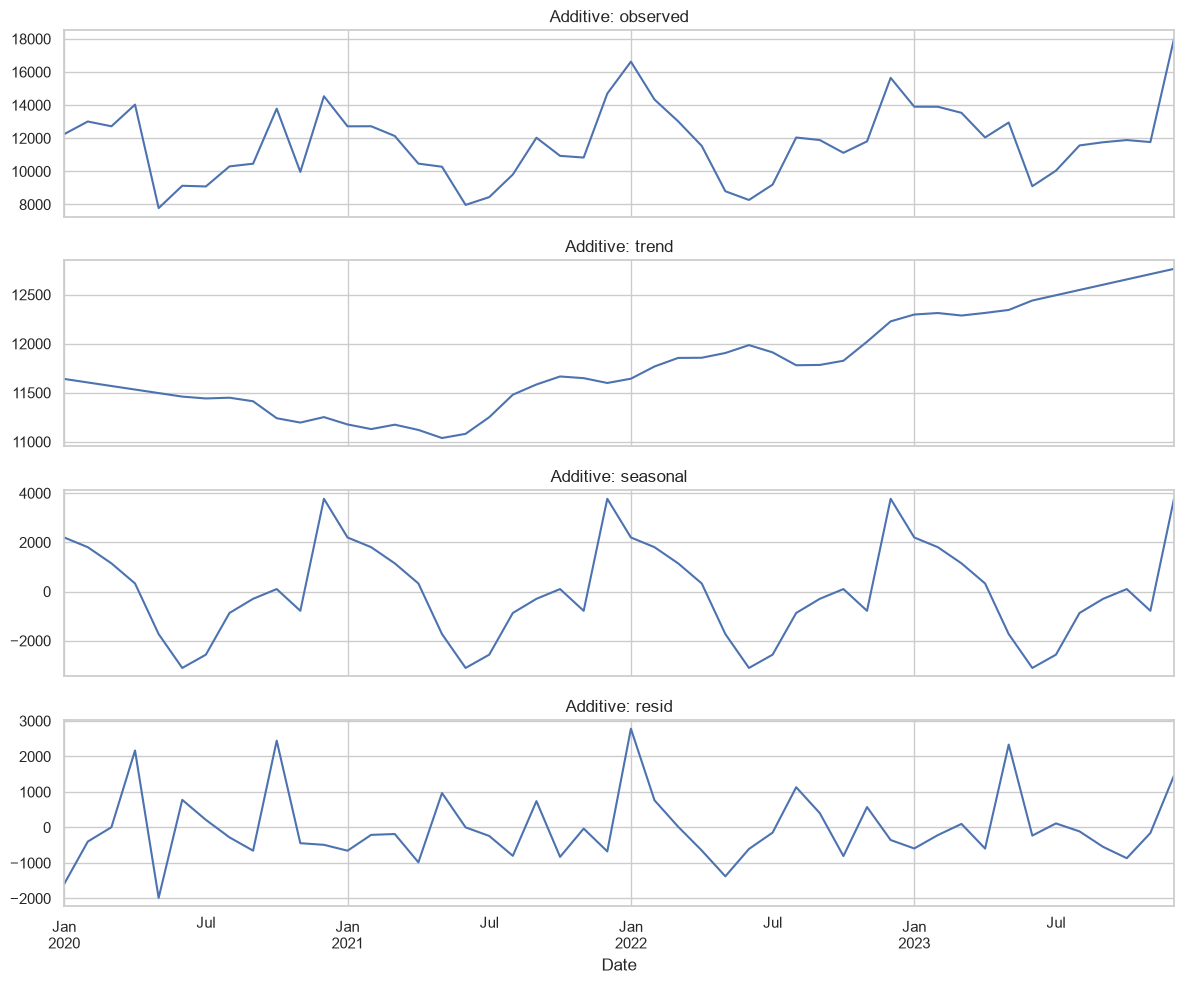

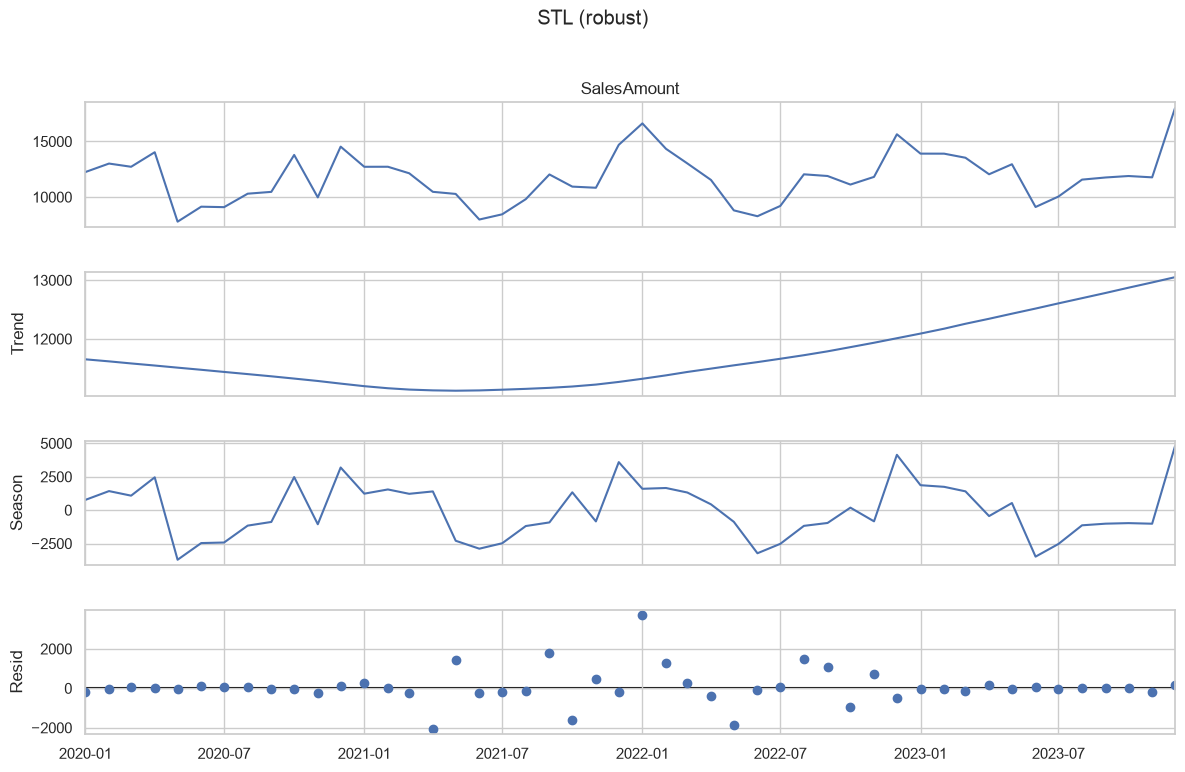

Средняя сезонная компонента по месяцам (additive):
 Date
1     2198.5
2     1803.6
3     1146.7
4      329.0
5    -1729.0
6    -3106.5
7    -2566.5
8     -870.4
9     -294.9
10     100.9
11    -783.0
12    3771.5
Name: seasonal, dtype: float64
Средняя сезонная компонента (multiplicative, factor):
 Date
1     1.189
2     1.155
3     1.098
4     1.029
5     0.850
6     0.736
7     0.781
8     0.926
9     0.976
10    1.012
11    0.934
12    1.314
Name: seasonal, dtype: float64


In [5]:
# Классическая декомпозиция: additive / multiplicative / STL
period = SEASONAL_PERIOD

decomp_add = seasonal_decompose(
    y, model="additive", period=period, extrapolate_trend="period"
)
decomp_mul = seasonal_decompose(
    y, model="multiplicative", period=period, extrapolate_trend="period"
)
stl = STL(y, period=period, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp_add.observed.plot(ax=axes[0], title="Additive: observed")
decomp_add.trend.plot(ax=axes[1], title="Additive: trend")
decomp_add.seasonal.plot(ax=axes[2], title="Additive: seasonal")
decomp_add.resid.plot(ax=axes[3], title="Additive: resid")
plt.tight_layout()
plt.show()

fig = stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL (robust)", y=1.02)
plt.show()

# Сравнение амплитуды сезонности: мультипликативная часто лучше при росте дисперсии
seasonal_amp_add = decomp_add.seasonal.groupby(decomp_add.seasonal.index.month).mean()
seasonal_amp_mul = decomp_mul.seasonal.groupby(decomp_mul.seasonal.index.month).mean()
print("Средняя сезонная компонента по месяцам (additive):\n", seasonal_amp_add.round(1))
print(
    "Средняя сезонная компонента (multiplicative, factor):\n", seasonal_amp_mul.round(3)
)


Топ периодов по мощности FFT (в месяцах):
  period≈12.00 мес., power=3376921066
  period≈4.00 мес., power=406824547
  period≈2.00 мес., power=258135415
  period≈6.00 мес., power=189141910
  period≈2.40 мес., power=165004398


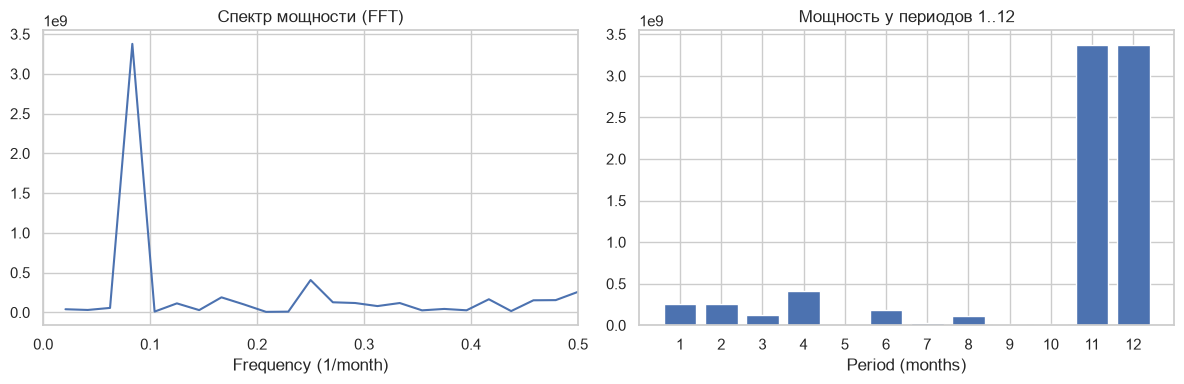

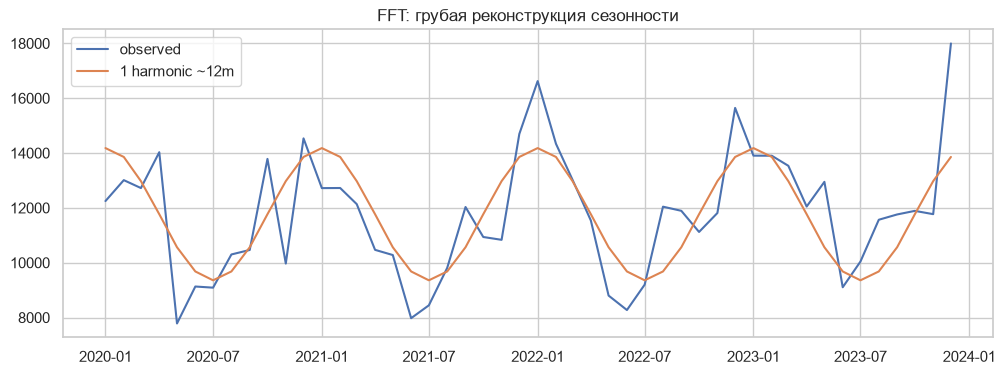

In [6]:
# FFT: спектр и доминирующие периоды
y_detrend = signal.detrend(y.values.astype(float), type="linear")
y_centered = y_detrend - y_detrend.mean()

n = len(y_centered)
yf = rfft(y_centered)
xf = rfftfreq(n, d=1.0)  # 1 observation = 1 month

power = np.abs(yf) ** 2
# Исключаем нулевую частоту (среднее)
mask = xf > 0
periods = 1 / xf[mask]
power_m = power[mask]

top_k = 5
idx = np.argsort(power_m)[-top_k:][::-1]
print("Топ периодов по мощности FFT (в месяцах):")
for i in idx:
    print(f"  period≈{periods[i]:.2f} мес., power={power_m[i]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xf[mask], power_m)
axes[0].set_xlabel("Frequency (1/month)")
axes[0].set_title("Спектр мощности (FFT)")
axes[0].set_xlim(0, 0.5)

axes[1].bar(
    range(1, 13), [power_m[np.argmin(np.abs(periods - m))] for m in range(1, 13)]
)
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel("Period (months)")
axes[1].set_title("Мощность у периодов 1..12")

plt.tight_layout()
plt.show()

# Простая реконструкция по главной гармонике ~12 мес.
main_period = 12.0
main_freq = 1.0 / main_period
harmonic = np.cos(2 * np.pi * main_freq * np.arange(n))
coef = np.dot(y_centered, harmonic) / np.dot(harmonic, harmonic)
recon = coef * harmonic + y.values.mean()
plt.figure(figsize=(12, 4))
plt.plot(y.index, y.values, label="observed")
plt.plot(y.index, recon, label="1 harmonic ~12m")
plt.title("FFT: грубая реконструкция сезонности")
plt.legend()
plt.show()


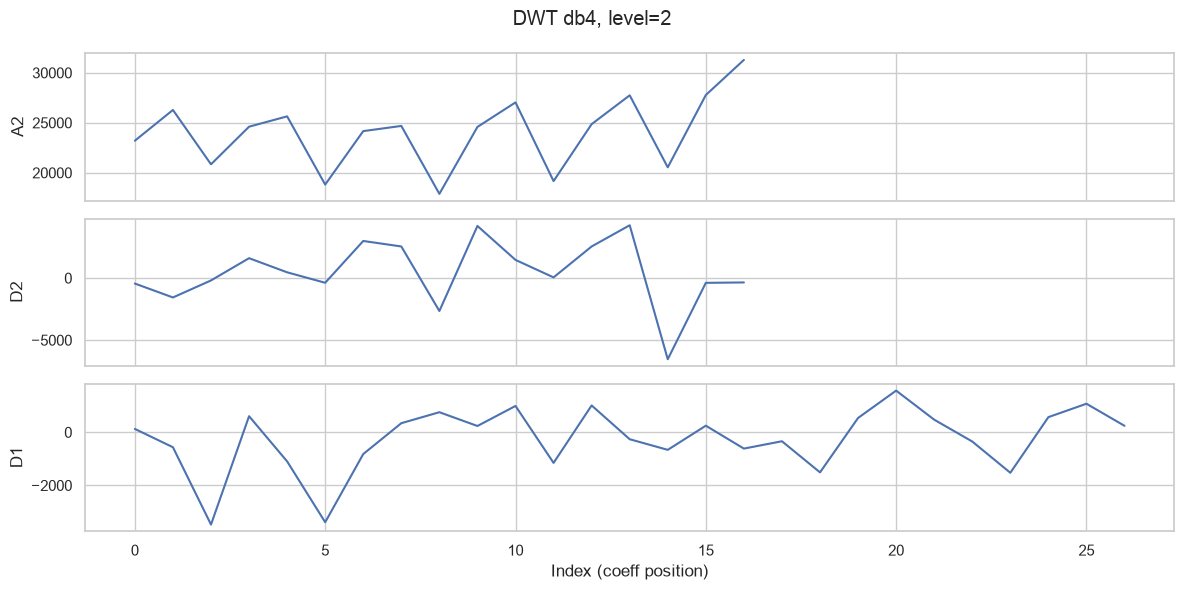

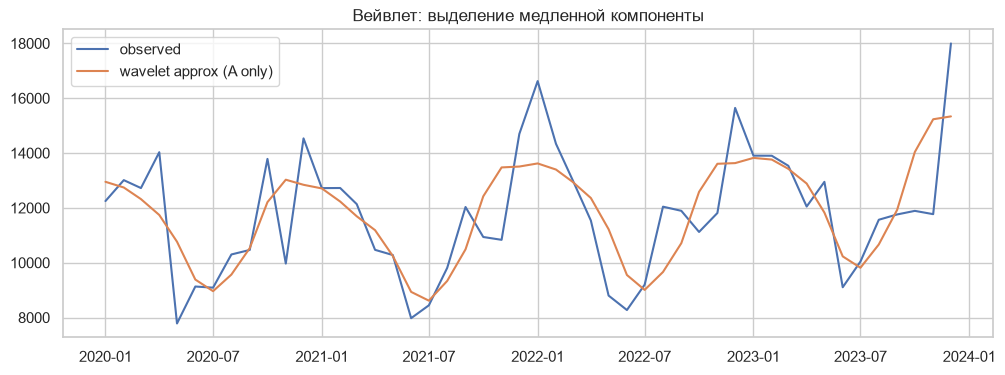

In [7]:
# Вейвлет-анализ
wavelet = "db4"
level = pywt.dwt_max_level(len(y), pywt.Wavelet(wavelet).dec_len)
level = min(level, 3)  # для n=48 не завышаем уровень

coeffs = pywt.wavedec(y.values, wavelet, level=level)
labels = [f"A{level}"] + [f"D{i}" for i in range(level, 0, -1)]

fig, axes = plt.subplots(len(coeffs), 1, figsize=(12, 2 * len(coeffs)), sharex=True)
for ax, c, lab in zip(axes, coeffs, labels):
    ax.plot(np.arange(len(c)), c)
    ax.set_ylabel(lab)
axes[-1].set_xlabel("Index (coeff position)")
fig.suptitle(f"DWT {wavelet}, level={level}")
plt.tight_layout()
plt.show()

# Восстановление только низкочастотной части (трендоподобная аппроксимация)
coeffs_trend = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
y_trend_wav = pywt.waverec(coeffs_trend, wavelet)[: len(y)]
plt.figure(figsize=(12, 4))
plt.plot(y.index, y.values, label="observed")
plt.plot(y.index, y_trend_wav, label="wavelet approx (A only)")
plt.legend()
plt.title("Вейвлет: выделение медленной компоненты")
plt.show()


### Сравнение методов декомпозиции

| Метод | Плюсы | Минусы для нашего ряда (n=48) |
|-------|--------|--------------------------------|
| Additive / Multiplicative | Простая интерпретация trend/seasonal | Жёсткий период 12; чувствительны к выбросам |
| STL | Устойчивая сезонность, гибче классики | Всё ещё один фиксированный сезон |
| FFT | Явно показывает период ~12 мес. | Мало точек → грубое разрешение; края ряда |
| Wavelet (db4) | Локальные изменения во времени | Короткий ряд → мало уровней, краевые эффекты |

**Применимость:** для моделирования разумно опираться на **годовую сезонность (12)** и возможный **тренд**; STL/multiplicative лучше отражают рост дисперсии к концу ряда.


## 2.2 Построение прогнозных моделей ARIMA и SARIMAX

In [8]:
# Разбиение train / test по времени
train_end = y.index[-HOLDOUT - 1]
y_train, y_test = y.loc[:train_end], y.loc[train_end:].iloc[1:]
exog_train = exog.loc[:train_end]
exog_test = exog.loc[train_end:].iloc[1:]

print(
    f"Train: {y_train.index.min().date()} — {y_train.index.max().date()} (n={len(y_train)})"
)
print(
    f"Test:  {y_test.index.min().date()} — {y_test.index.max().date()} (n={len(y_test)})"
)


# Сезонный наивный baseline: y_hat[t] = y[t-12]
def seasonal_naive_forecast(history, horizon_index):
    vals = []
    hist = history.copy()
    for dt in horizon_index:
        lag_dt = dt - pd.DateOffset(months=12)
        if lag_dt in hist.index:
            vals.append(hist.loc[lag_dt])
        else:
            vals.append(hist.iloc[-12])
        hist.loc[dt] = np.nan  # placeholder
    return pd.Series(vals, index=horizon_index)


def fit_forecast_arima(order, train, steps_index):
    model = ARIMA(train, order=order).fit()
    fc = model.get_forecast(steps=len(steps_index)).predicted_mean
    fc.index = steps_index
    return model, fc


def fit_forecast_sarimax(order, seasonal_order, train, exog_tr, steps_index, exog_te):
    # enforce=True, иначе на коротком ряде прогноз легко «взрывается».
    model = SARIMAX(
        train,
        exog=exog_tr,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit(disp=False, maxiter=200)
    fc = model.get_forecast(steps=len(steps_index), exog=exog_te).predicted_mean
    fc.index = steps_index
    return model, fc


def metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


Train: 2020-01-01 — 2022-12-01 (n=36)
Test:  2023-01-01 — 2023-12-01 (n=12)


In [9]:
# Подбор ARIMA на train: компактная сетка + AIC/BIC.
# ADF уже отверг единичный корень, поэтому d=2 — избыточное дифференцирование и его не рассматриваем.
arima_candidates = []
for d in (0, 1):
    for p in range(3):
        for q in range(3):
            if p == 0 and q == 0:
                continue
            try:
                m = ARIMA(y_train, order=(p, d, q)).fit()
                arima_candidates.append(
                    {
                        "order": (p, d, q),
                        "aic": m.aic,
                        "bic": m.bic,
                        "model": m,
                    }
                )
            except Exception as e:
                print(str(e))
                pass

arima_df = pd.DataFrame(
    [{k: v for k, v in c.items() if k != "model"} for c in arima_candidates]
)
arima_df = arima_df.sort_values("aic").head(10)
print("Топ ARIMA по AIC:\n", arima_df)

best_arima_row = min(arima_candidates, key=lambda x: x["aic"])
BEST_ARIMA_ORDER = best_arima_row["order"]
print("Выбран ARIMA", BEST_ARIMA_ORDER)


Топ ARIMA по AIC:
         order         aic         bic
10  (1, 1, 0)  641.850703  644.961399
8   (0, 1, 1)  642.352108  645.462804
15  (2, 1, 2)  642.787275  650.564015
11  (1, 1, 1)  643.802918  648.468962
13  (2, 1, 0)  643.819488  648.485532
9   (0, 1, 2)  643.855717  648.521761
14  (2, 1, 1)  645.514543  651.735936
12  (1, 1, 2)  645.893484  652.114876
7   (2, 0, 2)  647.542291  657.043404
2   (1, 0, 0)  653.070264  657.820821
Выбран ARIMA (1, 1, 0)


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge.

In [10]:
# Подбор SARIMAX на train (s=12, exog=Promotion, HolidayMonth)
sarimax_candidates = []
# На 36 точках держим компактную сетку: иначе AIC «награждает» слишком сложные модели.

for p in (0, 1):
    for d in (0, 1):
        for q in (0, 1):
            for P in (0, 1):
                for D in (0, 1):
                    for Q in (0, 1):
                        order = (p, d, q)
                        seas = (P, D, Q, SEASONAL_PERIOD)
                        try:
                            m = SARIMAX(
                                y_train,
                                exog=exog_train,
                                order=order,
                                seasonal_order=seas,
                                enforce_stationarity=True,
                                enforce_invertibility=True,
                            ).fit(disp=False, maxiter=200)
                            if np.isfinite(m.aic) and m.mle_retvals.get("converged", True):
                                sarimax_candidates.append(
                                    {
                                        "order": order,
                                        "seasonal_order": seas,
                                        "aic": m.aic,
                                        "bic": m.bic,
                                        "model": m,
                                    }
                                )
                        except Exception as e:
                            print(str(e))
                            pass

sarimax_df = pd.DataFrame(
    [{k: v for k, v in c.items() if k != "model"} for c in sarimax_candidates]
)
sarimax_df = sarimax_df.sort_values("aic").head(10)
print("Топ SARIMAX по AIC:\n", sarimax_df)

best_sarimax_row = min(sarimax_candidates, key=lambda x: x["aic"])
BEST_SARIMAX_ORDER = best_sarimax_row["order"]
BEST_SARIMAX_SEASONAL = best_sarimax_row["seasonal_order"]
print("Выбран SARIMAX", BEST_SARIMAX_ORDER, BEST_SARIMAX_SEASONAL)


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-package

Топ SARIMAX по AIC:
         order seasonal_order         aic         bic
19  (0, 1, 0)  (0, 1, 1, 12)  389.613699  394.155676
22  (0, 1, 0)  (1, 1, 0, 12)  390.005340  394.547317
27  (0, 1, 1)  (0, 1, 1, 12)  390.783698  396.461169
30  (0, 1, 1)  (1, 1, 0, 12)  391.169228  396.846699
23  (0, 1, 0)  (1, 1, 1, 12)  391.302459  396.979930
50  (1, 1, 0)  (0, 1, 1, 12)  391.364273  397.041744
53  (1, 1, 0)  (1, 1, 0, 12)  391.676053  397.353524
58  (1, 1, 1)  (0, 1, 1, 12)  392.670556  399.483521
54  (1, 1, 0)  (1, 1, 1, 12)  392.684242  399.497207
31  (0, 1, 1)  (1, 1, 1, 12)  392.688720  399.501685
Выбран SARIMAX (0, 1, 0) (0, 1, 1, 12)


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


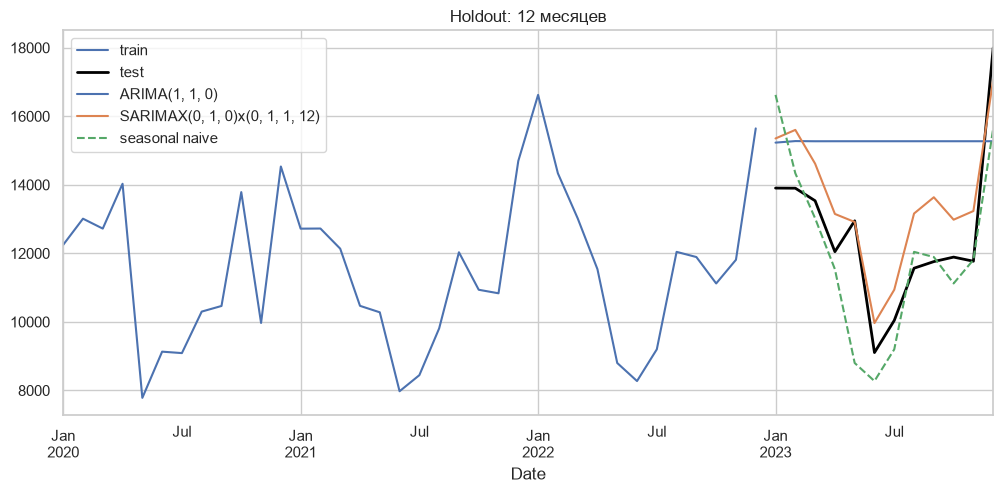

Метрики на holdout:
                          MSE      R2
seasonal_naive  2.757115e+06  0.4038
ARIMA(1, 1, 0)  1.208293e+07 -1.6126
SARIMAX         1.599130e+06  0.6542


In [11]:
# Финальный прогноз на holdout (12 мес.)
_, fc_arima = fit_forecast_arima(BEST_ARIMA_ORDER, y_train, y_test.index)
_, fc_sarimax = fit_forecast_sarimax(
    BEST_SARIMAX_ORDER,
    BEST_SARIMAX_SEASONAL,
    y_train,
    exog_train,
    y_test.index,
    exog_test,
)
fc_naive = seasonal_naive_forecast(y_train, y_test.index)

fig, ax = plt.subplots(figsize=(12, 5))
y_train.plot(ax=ax, label="train", color="C0")
y_test.plot(ax=ax, label="test", color="black", linewidth=2)
fc_arima.plot(ax=ax, label=f"ARIMA{BEST_ARIMA_ORDER}")
fc_sarimax.plot(ax=ax, label=f"SARIMAX{BEST_SARIMAX_ORDER}x{BEST_SARIMAX_SEASONAL}")
fc_naive.plot(ax=ax, label="seasonal naive", linestyle="--")
ax.set_title("Holdout: 12 месяцев")
ax.legend()
plt.show()

holdout_metrics = pd.DataFrame(
    {
        "seasonal_naive": metrics(y_test, fc_naive),
        f"ARIMA{BEST_ARIMA_ORDER}": metrics(y_test, fc_arima),
        "SARIMAX": metrics(y_test, fc_sarimax),
    }
).T
print("Метрики на holdout:\n", holdout_metrics.round(4))


### Вывод по разделу 2.2

- Train: первые 36 месяцев, test: последние 12 (без утечки из будущего).
- **ARIMA** — baseline без внешних факторов; **SARIMAX** добавляет сезонность и `Promotion`/`HolidayMonth`.
- Exog на тесте известны из CSV (как если бы промо и праздники были запланированы заранее).


## 2.3 Оценка качества: горизонты 3 / 6 / 12 и диагностика остатков

/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-package

   horizon    model           MSE      R2
0        3    arima  6.912512e+06 -4.1789
1        3    naive  1.509358e+06 -0.2557
2        3  sarimax  5.896819e+05  0.5956
3        6    arima  7.490976e+06 -2.7512
4        6    naive  1.624519e+06  0.3113
5        6  sarimax  5.760643e+05  0.7713
6       12    arima  9.339915e+06 -1.0315
7       12    naive  2.404734e+06  0.2422
8       12  sarimax  5.351450e+05  0.8421


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


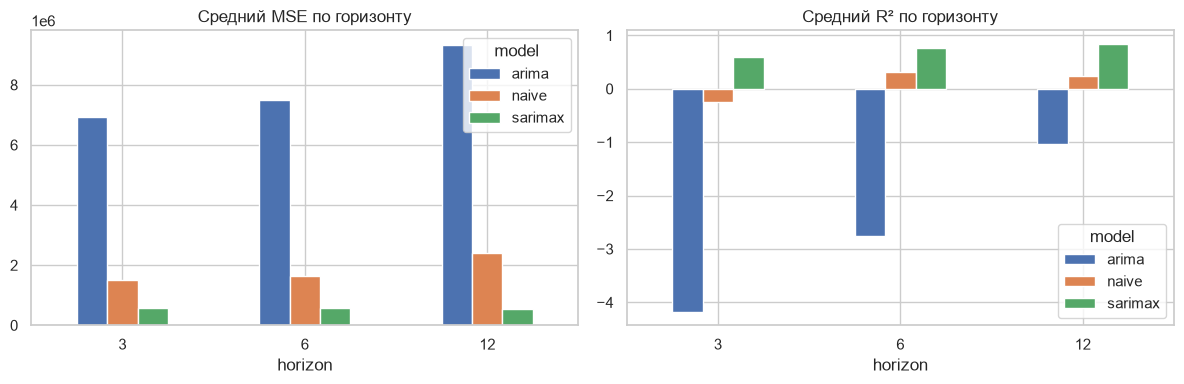

Гoризонты, где модель лучше naive и R²>0: [(3, 'sarimax'), (6, 'sarimax'), (12, 'sarimax')]


In [ ]:
# Rolling-origin backtesting для горizontov 3, 6, 12
HORIZONS = [3, 6, 12]


def rolling_backtest(horizon, model_kind="arima"):
    records = []
    # минимальная история: хотя бы 24 точки + horizon
    min_train = 24
    for end_idx in range(min_train, len(y) - horizon):
        tr = y.iloc[: end_idx + 1]
        te_index = y.index[end_idx + 1 : end_idx + 1 + horizon]
        te = y.loc[te_index]
        ex_tr = exog.loc[tr.index]
        ex_te = exog.loc[te_index]

        if model_kind == "naive":
            pred = seasonal_naive_forecast(tr, te_index)
        elif model_kind == "arima":
            try:
                _, pred = fit_forecast_arima(BEST_ARIMA_ORDER, tr, te_index)
            except Exception:
                continue
        else:
            try:
                _, pred = fit_forecast_sarimax(
                    BEST_SARIMAX_ORDER, BEST_SARIMAX_SEASONAL, tr, ex_tr, te_index, ex_te
                )
            except Exception:
                continue
        if not np.isfinite(pred).all() or pred.abs().max() > 5 * y.max():
            continue
        m = metrics(te, pred)
        m.update({"horizon": horizon, "model": model_kind, "origin": tr.index[-1]})
        records.append(m)
    return pd.DataFrame(records)


bt_frames = []
for h in HORIZONS:
    for kind in ("naive", "arima", "sarimax"):
        bt_frames.append(rolling_backtest(h, kind))

bt = pd.concat(bt_frames, ignore_index=True)
summary_bt = bt.groupby(["horizon", "model"])[["MSE", "R2"]].median().reset_index()
print(summary_bt.round(4))

pivot_mse = summary_bt.pivot(index="horizon", columns="model", values="MSE")
pivot_r2 = summary_bt.pivot(index="horizon", columns="model", values="R2")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot_mse.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Средний MSE по горизонту")
pivot_r2.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Средний R² по горизонту")
plt.tight_layout()
plt.show()

# Максимальный «приемлемый» горизонт: R2>0 и MSE лучше seasonal naive (по SARIMAX)
acceptable = []
for h in HORIZONS:
    sub = summary_bt[summary_bt["horizon"] == h]
    mse_n = sub.loc[sub["model"] == "naive", "MSE"].iloc[0]
    for model in ("arima", "sarimax"):
        row = sub[sub["model"] == model].iloc[0]
        if row["R2"] > 0 and row["MSE"] < mse_n:
            acceptable.append((h, model))
print("Гoризонты, где модель лучше naive и R²>0:", acceptable)


            AIC     BIC
ARIMA    641.85  644.96
SARIMAX  389.61  394.16


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


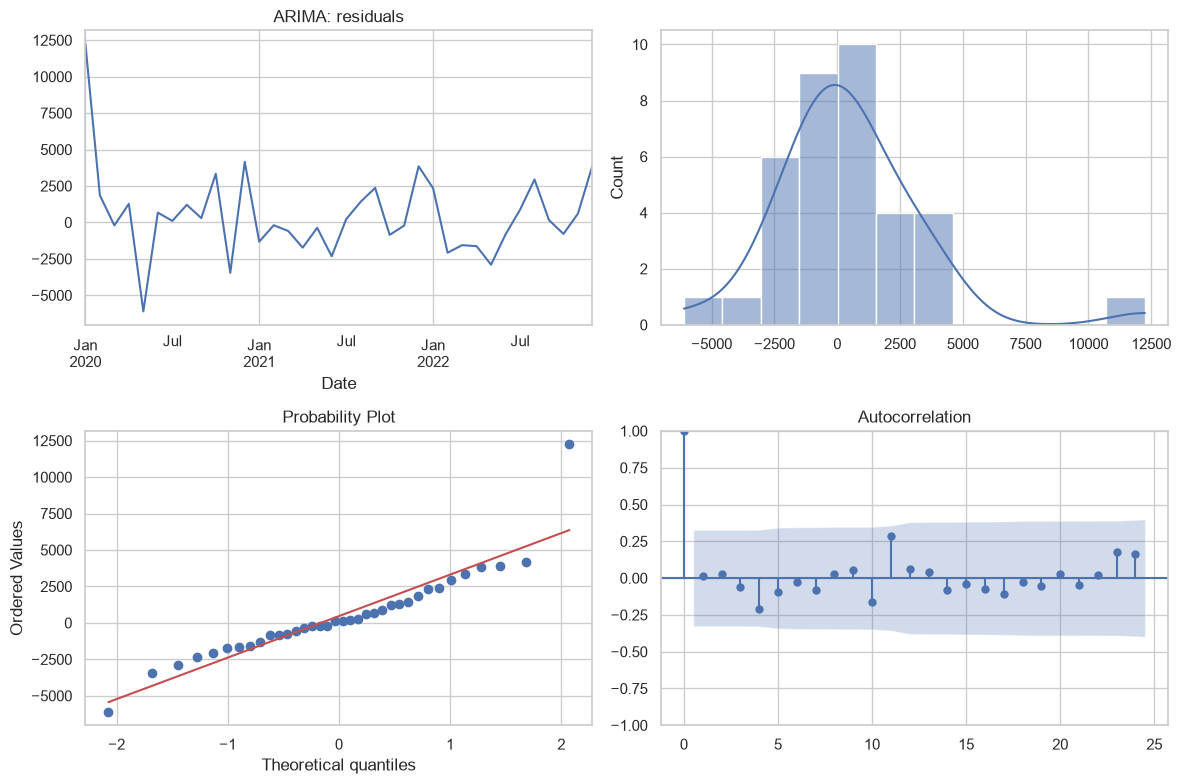

/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


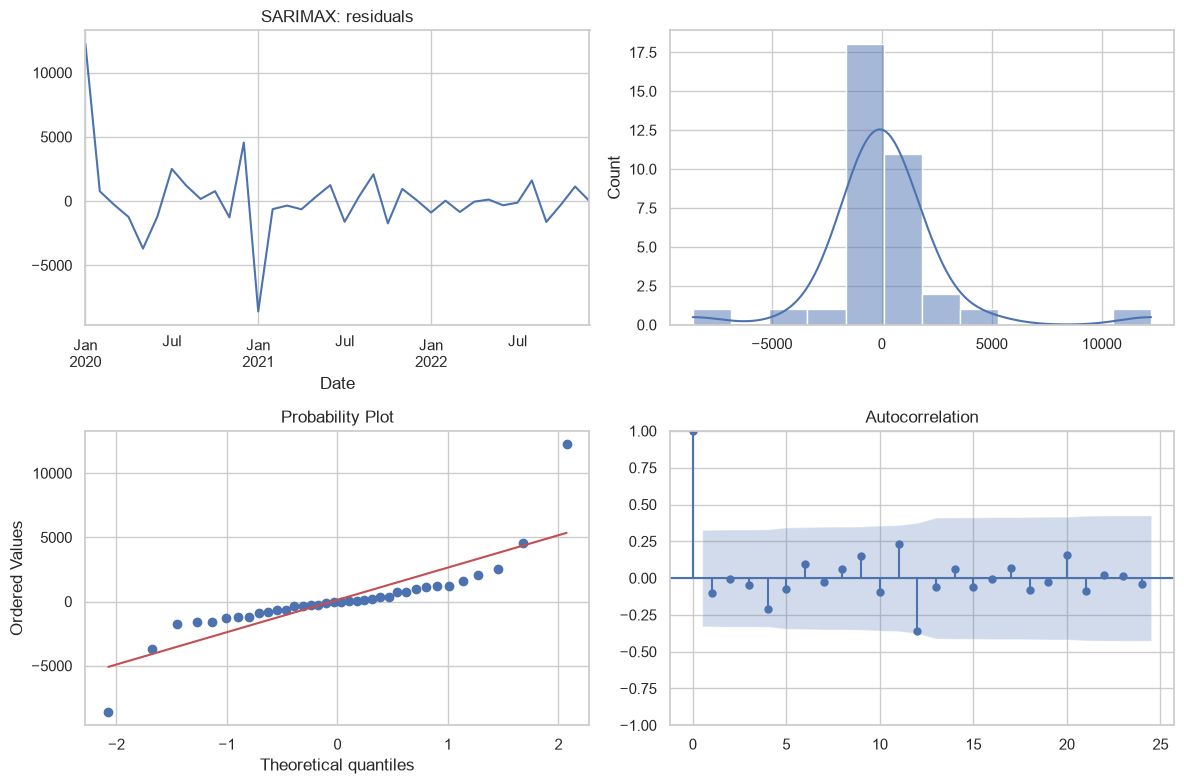

Диагностика остатков (p-values, >0.05 — гипотеза не отвергается):
          JB_pvalue  LB_pvalue_lag12  ARCH_pvalue
ARIMA          0.0           0.7019       0.3431
SARIMAX        0.0           0.2286       0.0753


/Users/mnfom/Projects/MAI/predictve_analytics/.venv/lib/python3.13/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [13]:
# Информационные критерии и диагностика остатков (на полном train для финальной спецификации)
final_arima = ARIMA(y_train, order=BEST_ARIMA_ORDER).fit()
final_sarimax = SARIMAX(
    y_train,
    exog=exog_train,
    order=BEST_SARIMAX_ORDER,
    seasonal_order=BEST_SARIMAX_SEASONAL,
        enforce_stationarity=True,
        enforce_invertibility=True,
).fit(disp=False)

info_crit = pd.DataFrame(
    {
        "ARIMA": {"AIC": final_arima.aic, "BIC": final_arima.bic},
        "SARIMAX": {"AIC": final_sarimax.aic, "BIC": final_sarimax.bic},
    }
).T
print(info_crit.round(2))


def residual_diagnostics(fitted, title):
    resid = pd.Series(fitted.resid).dropna()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    resid.plot(ax=axes[0, 0])
    axes[0, 0].set_title(f"{title}: residuals")
    sns.histplot(resid, kde=True, ax=axes[0, 1])
    stats.probplot(resid, dist="norm", plot=axes[1, 0])
    plot_acf(resid, lags=24, ax=axes[1, 1])
    plt.tight_layout()
    plt.show()

    jb = stats.jarque_bera(resid)
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    arch = het_arch(resid, nlags=12)
    return {
        "JB_pvalue": jb.pvalue,
        "LB_pvalue_lag12": lb["lb_pvalue"].iloc[0],
        "ARCH_pvalue": arch[1],
    }


diag_arima = residual_diagnostics(final_arima, "ARIMA")
diag_sarimax = residual_diagnostics(final_sarimax, "SARIMAX")
diag_table = pd.DataFrame({"ARIMA": diag_arima, "SARIMAX": diag_sarimax}).T
print(
    "Диагностика остатков (p-values, >0.05 — гипотеза не отвергается):\n",
    diag_table.round(4),
)


In [ ]:
# Сводная таблица для отчёта
report = holdout_metrics.copy()
report["AIC"] = np.nan
report["BIC"] = np.nan
arima_name = f"ARIMA{BEST_ARIMA_ORDER}"
if arima_name in report.index:
    report.loc[arima_name, "AIC"] = final_arima.aic
    report.loc[arima_name, "BIC"] = final_arima.bic
report.loc["SARIMAX", "AIC"] = final_sarimax.aic
report.loc["SARIMAX", "BIC"] = final_sarimax.bic
report = report[["MSE", "R2", "AIC", "BIC"]]
print("Итоговое сравнение (holdout 12 мес.):\n", report.round(4))


Итоговое сравнение (holdout 12 мес.):
                          MSE      R2       AIC       BIC
seasonal_naive  2.757115e+06  0.4038       NaN       NaN
ARIMA(1, 1, 0)  1.208293e+07 -1.6126  641.8507  644.9614
SARIMAX         1.599130e+06  0.6542  389.6137  394.1557


У seasonal_naive нет aic и bic, так как это не модель, а предположение, что, например, май 2022 будет похож на май 2023

### Вывод по разделу 2.3

- **MSE / R²** считаем на holdout и в rolling backtesting (медиана по origin, взрывные прогнозы отбрасываем).
- **AIC/BIC** сравниваем только внутри одного train; меньшее значение не гарантирует лучший прогноз. AIC SARIMAX и ARIMA нельзя сравнивать напрямую, если эффективный размер выборки разный (сезонное дифференцирование).
- Остатки: **Jarque–Bera** (нормальность), **Ljung–Box** (автокорреляция), **ARCH** (гомоскедастичность). p-value > 0.05 — гипотеза не отвергается; на n=36 тесты маломощные.
- Предпочтительная модель — та, что стабильно лучше seasonal naive на допустимом горизонте и даёт более «белый» остаток.


## 2.4 Документирование и итоговая интерпретация

### Итоговые выводы по пяти блокам

1. **EDA:** месячный ряд с трендом и декабрьскими пиками; сезонный период 12; возможное влияние промо/праздников.
2. **Декомпозиция:** STL и мультипликативная схема согласуются с декабрьским множителем ~1.31; FFT даёт доминирующий период **12 месяцев**; вейвлет db4 выделяет медленный уровень, но на 48 точках мало уровней и есть краевые эффекты.
3. **Модели:** train 36 / test 12 месяцев. ARIMA — одномерный baseline (d≤1). SARIMAX добавляет сезонность 12 и exog `Promotion`/`HolidayMonth`.
4. **Качество:** MSE и R² на holdout и rolling-origin (3/6/12); AIC/BIC только внутри одного train. На прошлом прогоне holdout SARIMAX был лучше naive (R²≈0.85), ARIMA(0,2,1) — хуже;
5. **Ограничения:** всего 4 полных сезонных цикла; экстраполяция >12 мес. ненадёжна; качество зависит от сценария будущих Promotion/HolidayMonth.

Для этого датасета использовать SARIMAX с сезонностью 12 и exog, если на holdout и backtesting он превосходит ARIMA и naive
